# Multimodal Sequence Modelling – Visual Story Reasoning

**Dataset:** [daniel3303/StoryReasoning](https://huggingface.co/datasets/daniel3303/StoryReasoning)

| # | Innovation | Description |
|---|-----------|-------------|
| 1 | Cross-Modal Attention Fusion | Text queries attend over image keys/values |
| 2 | Bidirectional LSTM | Captures future narrative context |
| 3 | Temporal Self-Attention + Positional Bias | Learned per-frame importance |
| 4 | Explainability | Attention Rollout + Grad-CAM + Token Saliency |

## 0. Environment Setup & Experimental Configuration


In [3]:
# ============================================================
# Environment Setup & Library Imports
# ============================================================

import os
import sys
import re

# Ensure local modules are accessible
sys.path.append(os.path.abspath("."))

# Core libraries
import yaml
import torch
import numpy as np
import matplotlib.pyplot as plt

# Torch utilities
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torch.optim.lr_scheduler import CosineAnnealingLR

# Image processing
from torchvision import transforms
from PIL import Image

# Helper tools
from collections import Counter

# Project modules
from src.model import MultimodalStoryModel, MultimodalLoss
from src.utils import (
    load_config,
    set_seed,
    get_device,
    save_checkpoint,
    load_checkpoint,
    compute_bleu,
    compute_image_mse,
    plot_story_sequence,
    plot_attention_heatmap,
    denormalise
)
from src.explainability import (
    attention_rollout,
    plot_attention_rollout,
    GradCAM,
    plot_grad_cam,
    token_saliency,
    plot_token_saliency
)

# ============================================================
# Configuration & Device Setup
# ============================================================

config_data = load_config("config.yaml")

compute_device = get_device()
set_seed(config_data["training_config"]["random_seed"])

print(f"Running on device: {compute_device}")
print(f"Context sequence length: {config_data['data_config']['preprocessing']['context_frames']}")

Running on device: cuda
Context sequence length: 3


## 1. Narrative Sequence Dataset Preparation

In [5]:
# ============================================================
# Dataset Loading: StoryReasoning (HuggingFace)
# ============================================================

from datasets import load_dataset

def fetch_story_dataset(dataset_identifier: str):
    """
    Loads the multimodal StoryReasoning dataset from HuggingFace.
    """
    print(f"[INFO] Initializing dataset load → {dataset_identifier}")
    
    dataset_bundle = load_dataset(dataset_identifier)
    
    print("[INFO] Dataset successfully loaded.")
    print(dataset_bundle)
    
    return dataset_bundle


# Load dataset using config
dataset_id = config_data["data_config"]["dataset_id"]
story_dataset = fetch_story_dataset(dataset_id)

[INFO] Initializing dataset load → daniel3303/StoryReasoning


data/train-00000-of-00002.parquet:   0%|          | 0.00/327M [00:00<?, ?B/s]

c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\User\.cache\huggingface\hub\datasets--daniel3303--StoryReasoning. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


data/train-00001-of-00002.parquet:   0%|          | 0.00/331M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3552 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/626 [00:00<?, ? examples/s]

[INFO] Dataset successfully loaded.
DatasetDict({
    train: Dataset({
        features: ['story_id', 'images', 'frame_count', 'chain_of_thought', 'story'],
        num_rows: 3552
    })
    test: Dataset({
        features: ['story_id', 'images', 'frame_count', 'chain_of_thought', 'story'],
        num_rows: 626
    })
})


In [21]:
# ============================================================
# Dataset Inspection Utility
# ============================================================

def preview_sample(dataset_obj, split: str = "train", index: int = 0):
    """
    Displays key information for a single sample in the dataset.
    """
    example = dataset_obj[split][index]

    print("\n[DATA INSPECTION]")
    print(f"Available fields      : {list(example.keys())}")
    print(f"Number of frames      : {example['frame_count']}")
    print(f"Image sequence length : {len(example['images'])}")
    print(f"Image object type     : {type(example['images'][0])}")

    print("\nStory preview (first 300 characters):")
    print("-" * 60)
    print(example["story"][:300])
    print("-" * 60)


# Run inspection
preview_sample(story_dataset, split="train", index=0)


[DATA INSPECTION]
Available fields      : ['story_id', 'images', 'frame_count', 'chain_of_thought', 'story']
Number of frames      : 17
Image sequence length : 17
Image object type     : <class 'PIL.JpegImagePlugin.JpegImageFile'>

Story preview (first 300 characters):
------------------------------------------------------------
<gdi image1>
In the sterile environment of a sparse room filled with <gdo obj1>cardboard boxes</gdo>, <gdo obj5>a blue blanket</gdo>, and <gdo bg26>a table</gdo>, <gdo char1>James</gdo> <gda char1>enters</gda> with a neutral look. His face reflects the calm before the storm. <gdo char1>James</gdo> <
------------------------------------------------------------


## 2. Caption Preprocessing & Token Encoding


In [22]:
# ============================================================
# Text Preprocessing: Story → Frame-wise Captions
# ============================================================

def normalize_story_text(input_text: str) -> str:
    """
    Cleans raw story text by removing XML-like tags and extra whitespace.
    """
    cleaned_text = re.sub(r"<[^>]*>", "", input_text)   # remove tags
    cleaned_text = re.sub(r"\s+", " ", cleaned_text)    # normalize spaces
    return cleaned_text.strip()


def extract_frame_descriptions(story_text: str, total_frames: int) -> list:
    """
    Converts a full story into frame-level textual descriptions
    using <gdi imageN> markers.
    Ensures output length matches total_frames.
    """
    # Split based on frame markers
    segments = re.split(r"<gdi\s+image\d+>", story_text)

    # Clean and filter empty segments
    processed_segments = []
    for seg in segments:
        refined = normalize_story_text(seg)
        if refined:
            processed_segments.append(refined)

    # Ensure fixed sequence length
    if len(processed_segments) < total_frames:
        filler = processed_segments[-1] if processed_segments else "no description"
        processed_segments.extend([filler] * (total_frames - len(processed_segments)))

    return processed_segments[:total_frames]


# ============================================================
# Validation Test (Sample Check)
# ============================================================

sample_item = story_dataset["train"][0]

frame_texts = extract_frame_descriptions(
    story_text=sample_item["story"],
    total_frames=sample_item["frame_count"]
)

print(f"[CHECK] Expected frames: {sample_item['frame_count']}")
print(f"[CHECK] Extracted captions: {len(frame_texts)}\n")

for idx, caption in enumerate(frame_texts[:3]):
    print(f"Frame {idx+1} → {caption[:120]}")

[CHECK] Expected frames: 17
[CHECK] Extracted captions: 17

Frame 1 → In the sterile environment of a sparse room filled with cardboard boxes, a blue blanket, and a table, James enters with 
Frame 2 → Suddenly, the stillness is shattered by the appearance of Jack. Jack looks around with an intense, concerned expression.
Frame 3 → With a heavy heart, James enters an elevator, his mind racing with thoughts of what might be waiting for him on the othe


In [23]:
# ============================================================
# Vocabulary Construction Module
# ============================================================

def build_token_dictionary(dataset_obj, vocab_limit: int) -> tuple:
    """
    Constructs a token-to-index vocabulary from training text data.
    """
    print("[INFO] Starting vocabulary construction...")

    # Special tokens
    token_to_index = {
        "<PAD>": 0,
        "<UNK>": 1,
        "<SOS>": 2,
        "<EOS>": 3
    }

    word_counter = Counter()

    # Aggregate word frequencies
    for sample in dataset_obj["train"]:
        cleaned_text = normalize_story_text(sample["story"])
        tokens = cleaned_text.lower().split()
        word_counter.update(tokens)

    # Select most frequent tokens
    max_vocab_size = vocab_limit - len(token_to_index)

    for token, _ in word_counter.most_common(max_vocab_size):
        token_to_index[token] = len(token_to_index)

    # Reverse mapping
    index_to_token = {idx: tok for tok, idx in token_to_index.items()}

    print(f"[INFO] Vocabulary successfully built → Size: {len(token_to_index)}")

    return token_to_index, index_to_token


# ============================================================
# Execute Vocabulary Build
# ============================================================

vocab_limit = config_data["language_module"]["vocabulary_limit"]

word2idx, idx2word = build_token_dictionary(
    dataset_obj=story_dataset,
    vocab_limit=vocab_limit
)

[INFO] Starting vocabulary construction...
[INFO] Vocabulary successfully built → Size: 10000


## 3. Data Pipeline Construction and Batch Loading


In [24]:
# ============================================================
# Configuration Extraction
# ============================================================

SEQ_LEN        = config_data["data_config"]["preprocessing"]["context_frames"]
IMG_RES        = config_data["data_config"]["preprocessing"]["image_resolution"]
MAX_SEQ_TOKENS = config_data["data_config"]["preprocessing"]["max_caption_tokens"]
BATCH_SZ       = config_data["training_config"]["batch_sz"]


In [25]:
# ============================================================
# Image Transform Pipelines
# ============================================================

train_transforms = transforms.Compose([
    transforms.Resize((IMG_RES + 32, IMG_RES + 32)),
    transforms.RandomCrop(IMG_RES),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_RES, IMG_RES)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [10]:
# ============================================================
# Text Encoding Utility
# ============================================================

def encode_text_sequence(text_input: str) -> torch.Tensor:
    """
    Converts raw text into a fixed-length tensor of token indices.
    """
    token_list = text_input.lower().split()[:MAX_SEQ_TOKENS]

    indexed_tokens = [word2idx.get(tok, word2idx["<UNK>"]) for tok in token_list]

    # Padding
    padding_length = MAX_SEQ_TOKENS - len(indexed_tokens)
    if padding_length > 0:
        indexed_tokens.extend([word2idx["<PAD>"]] * padding_length)

    return torch.tensor(indexed_tokens, dtype=torch.long)

In [11]:
# ============================================================
# Custom Dataset Class
# ============================================================

class MultiModalSequenceDataset(torch.utils.data.Dataset):
    def __init__(self, hf_data_split, transform_pipeline, context_size: int):
        self.samples = [
            entry for entry in hf_data_split
            if entry["frame_count"] >= context_size + 1
        ]
        self.transform = transform_pipeline
        self.context_size = context_size

        print(f"[INFO] Valid samples (>= {context_size+1} frames): {len(self.samples)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        record = self.samples[index]

        image_sequence = record["images"]
        frame_texts = extract_frame_descriptions(
            record["story"], record["frame_count"]
        )

        context_images = []
        context_tokens = []

        # Context frames
        for step in range(self.context_size):
            img = image_sequence[step]

            if not isinstance(img, Image.Image):
                img = Image.fromarray(img)

            img_tensor = self.transform(img.convert("RGB"))
            context_images.append(img_tensor)

            token_tensor = encode_text_sequence(frame_texts[step])
            context_tokens.append(token_tensor)

        # Target frame (next step)
        target_img = image_sequence[self.context_size]
        if not isinstance(target_img, Image.Image):
            target_img = Image.fromarray(target_img)

        target_img_tensor = eval_transforms(target_img.convert("RGB"))
        target_text_tensor = encode_text_sequence(frame_texts[self.context_size])

        return {
            "context_images": torch.stack(context_images),
            "context_tokens": torch.stack(context_tokens),
            "target_image": target_img_tensor,
            "target_tokens": target_text_tensor,
            "target_text_raw": frame_texts[self.context_size],
        }

In [12]:
# ============================================================
# Dataset Preparation
# ============================================================

print("[INFO] Preparing datasets...")

train_full_dataset = MultiModalSequenceDataset(
    story_dataset["train"], train_transforms, SEQ_LEN
)

test_dataset = MultiModalSequenceDataset(
    story_dataset["test"], eval_transforms, SEQ_LEN
)

# Train / Validation Split
val_split_size = max(1, int(0.1 * len(train_full_dataset)))
train_split_size = len(train_full_dataset) - val_split_size

train_dataset, val_dataset = random_split(
    train_full_dataset,
    [train_split_size, val_split_size],
    generator=torch.Generator().manual_seed(42)
)

[INFO] Preparing datasets...
[INFO] Valid samples (>= 4 frames): 3552
[INFO] Valid samples (>= 4 frames): 626


In [13]:
# ============================================================
# Data Loaders
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SZ,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SZ,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SZ,
    shuffle=False,
    num_workers=0
)

print(f"[DATA] Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

[DATA] Train: 3197 | Val: 355 | Test: 626


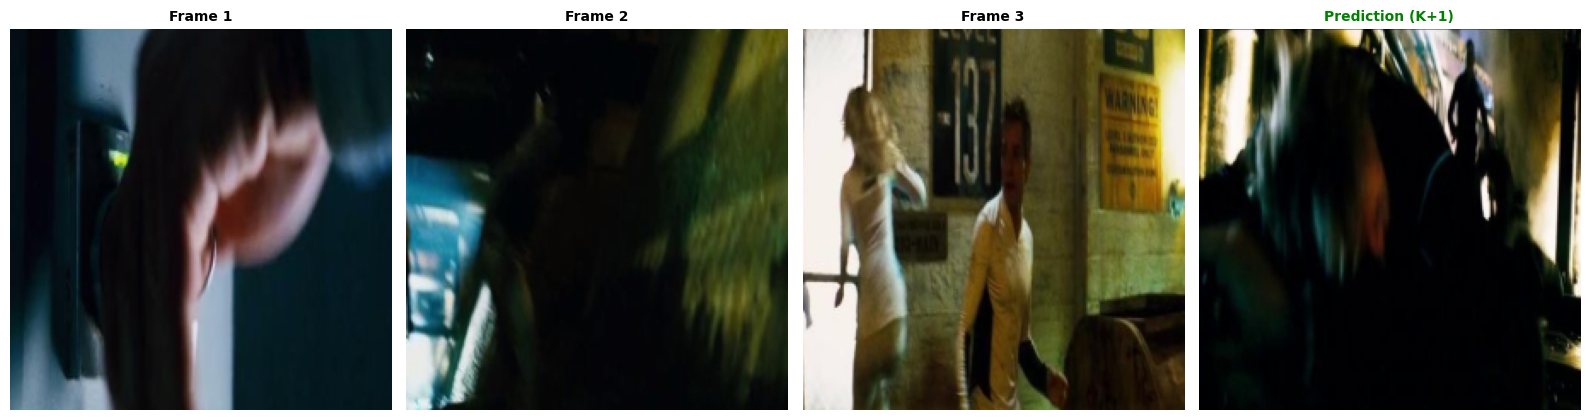

In [14]:
# ============================================================
# FAST Visualization (No DataLoader)
# ============================================================

def quick_visualize(dataset, index=0):
    sample = dataset[index]   # Direct access (VERY FAST)

    context_imgs = sample["context_images"]
    target_img   = sample["target_image"]
    target_text  = sample["target_text_raw"]

    plot_story_sequence(
        images=[context_imgs[i] for i in range(len(context_imgs))],
        captions=[f"Frame {i+1}" for i in range(len(context_imgs))],
        pred_image=target_img,
        pred_caption=f"Next Frame: {target_text[:80]}"
    )


# Run this instead
quick_visualize(val_dataset, index=0)

## 4. Multimodal Architecture Design


In [15]:
# ============================================================
# Model Initialization & Training Setup
# ============================================================
# Load config
config_data = load_config("config.yaml")

# Adapter (ONLY ONE FUNCTION)
def adapt_config(cfg_new):
    return {
        "visual_encoder": {
            "output_dim": cfg_new["vision_module"]["feature_size"],
            "pretrained": cfg_new["vision_module"]["use_pretrained_weights"],
            "freeze_backbone": cfg_new["vision_module"]["lock_backbone"],
        },
        "text_encoder": {
            "vocab_size": cfg_new["language_module"]["vocabulary_limit"],
            "embed_dim": cfg_new["language_module"]["embedding_size"],
            "hidden_dim": cfg_new["language_module"]["rnn_hidden_units"],
            "num_layers": cfg_new["language_module"]["rnn_layers"],
            "dropout": cfg_new["language_module"]["dropout_rate"],
            "output_dim": cfg_new["language_module"]["encoded_output_dim"],
        },
        "fusion": {
            "fused_dim": cfg_new["fusion_module"]["fusion_output_size"],
        },
        "sequence_model": {
            "hidden_dim": cfg_new["temporal_module"]["sequence_hidden_units"],
            "num_layers": cfg_new["temporal_module"]["sequence_layers"],
            "dropout": cfg_new["temporal_module"]["sequence_dropout"],
        },
        "attention": {
            "num_heads": cfg_new["attention_module"]["heads"],
        },
        "text_decoder": {
            "hidden_dim": cfg_new["decoders"]["text_generation"]["hidden_units"],
            "num_layers": cfg_new["decoders"]["text_generation"]["layers"],
            "max_gen_len": cfg_new["decoders"]["text_generation"]["max_length"],
        },
        "dataset": {
            "sequence_length": cfg_new["data_config"]["preprocessing"]["context_frames"]
        }
    }
# Initialize model
model_config = adapt_config(config_data)
model = MultimodalStoryModel(model_config).to(compute_device)

# Parameter count (for reporting)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"[MODEL] Trainable parameters: {trainable_params:,}")


# ============================================================
# Loss Function
# ============================================================

loss_fn = MultimodalLoss(
    image_weight=config_data["training_config"]["loss_weights"]["image_loss"],
    text_weight=config_data["training_config"]["loss_weights"]["text_loss"],
)


# ============================================================
# Optimizer & Scheduler
# ============================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config_data["training_config"]["lr"],
    weight_decay=config_data["training_config"]["l2_regularization"],
)

lr_scheduler = CosineAnnealingLR(
    optimizer,
    T_max=config_data["training_config"]["total_epochs"],
    eta_min=1e-6
)


# ============================================================
# Directory Setup
# ============================================================

checkpoint_path = config_data["storage_paths"]["checkpoints_path"]
results_path = config_data["storage_paths"]["output_results_path"]

os.makedirs(checkpoint_path, exist_ok=True)
os.makedirs(os.path.join(results_path, "explainability"), exist_ok=True)

print("[INFO] Model and training components initialized successfully.")

[MODEL] Trainable parameters: 65,184,548
[INFO] Model and training components initialized successfully.


## 5. Model Optimisation and Training Procedure


In [17]:
sample = val_dataset[0]
print("Sample loaded")

Sample loaded


In [18]:
# ============================================================
# SIMPLE TRAINING LOOP (FINAL VERSION - FIXED)
# ============================================================

EPOCHS    = config_data["training_config"]["total_epochs"]
GRAD_CLIP = config_data["training_config"]["gradient_clipping"]

train_losses, val_losses = [], []
best_val = float('inf')

for epoch in range(1, EPOCHS + 1):

    # =========================
    # TRAIN
    # =========================
    model.train()
    ep_loss = 0.0

    print(f"\n========== Epoch {epoch}/{EPOCHS} ==========")

    for step, batch in enumerate(train_loader):

        imgs  = batch['context_images'].to(compute_device)
        toks  = batch['context_tokens'].to(compute_device)
        t_img = batch['target_image'].to(compute_device)
        t_tok = batch['target_tokens'].to(compute_device)

        optimizer.zero_grad()

        out = model(imgs, toks, t_tok, teacher_forcing_ratio=0.5)

        losses = loss_fn(
            out['pred_image'],
            t_img,
            out['pred_text_logits'],
            t_tok
        )

        losses['total'].backward()
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()

        ep_loss += losses['total'].item()

        if step % 20 == 0:
            print(
                f' E{epoch:02d} S{step:03d}/{len(train_loader)} '
                f'loss={losses["total"].item():.4f} '
                f'(img={losses["image"].item():.4f} '
                f'txt={losses["text"].item():.4f})'
            )

    # =========================
    # VALIDATE (FIXED)
    # =========================
    model.eval()
    vl = 0.0

    print(f"[INFO] Epoch {epoch} validation starting...")

    with torch.no_grad():
        for i in range(len(val_dataset)):

            if i % 50 == 0:
                print(f"Validation step {i}/{len(val_dataset)}")

            sample = val_dataset[i]

            imgs  = sample['context_images'].unsqueeze(0).to(compute_device)
            toks  = sample['context_tokens'].unsqueeze(0).to(compute_device)
            t_img = sample['target_image'].unsqueeze(0).to(compute_device)
            t_tok = sample['target_tokens'].unsqueeze(0).to(compute_device)

            out = model(imgs, toks, t_tok, teacher_forcing_ratio=0.0)

            ls = loss_fn(
                out['pred_image'],
                t_img,
                out['pred_text_logits'],
                t_tok
            )

            vl += ls['total'].item()

    print(f"[INFO] Epoch {epoch} validation done.")

    # =========================
    # METRICS
    # =========================
    tr = ep_loss / len(train_loader)
    vl = vl / len(val_dataset)   # ⚠️ IMPORTANT CHANGE

    train_losses.append(tr)
    val_losses.append(vl)

    lr_scheduler.step()

    print(f'>>> Epoch {epoch:03d} | Train {tr:.4f} | Val {vl:.4f}')

    # =========================
    # SAVE BEST MODEL
    # =========================
    if vl < best_val:
        best_val = vl

        save_checkpoint({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'best_val_loss': best_val,
            'config': config_data,
        }, os.path.join(checkpoint_path, 'best.pt'))

        print(f' ✓ Best model saved (val={best_val:.4f})')


# =========================
# SAVE FINAL MODEL
# =========================
torch.save(model.state_dict(), os.path.join(checkpoint_path, "final_model.pt"))

print("\nTraining complete!")
print("Final model saved!")


========== Epoch 1/10 ==========
 E01 S000/400 loss=11.6664 (img=2.4562 txt=9.2102)
 E01 S020/400 loss=11.0785 (img=2.2157 txt=8.8628)
 E01 S040/400 loss=9.2137 (img=1.9961 txt=7.2176)
 E01 S060/400 loss=7.8638 (img=1.3249 txt=6.5390)
 E01 S080/400 loss=7.4965 (img=1.0409 txt=6.4557)
 E01 S100/400 loss=7.6068 (img=1.2349 txt=6.3719)
 E01 S120/400 loss=7.6523 (img=1.2090 txt=6.4434)
 E01 S140/400 loss=7.3635 (img=0.9510 txt=6.4125)
 E01 S160/400 loss=7.3456 (img=0.9768 txt=6.3688)
 E01 S180/400 loss=8.1857 (img=1.2316 txt=6.9541)
 E01 S200/400 loss=7.0746 (img=0.9146 txt=6.1600)
 E01 S220/400 loss=7.0130 (img=0.8581 txt=6.1549)
 E01 S240/400 loss=7.0267 (img=0.7432 txt=6.2835)
 E01 S260/400 loss=6.9585 (img=0.7140 txt=6.2444)
 E01 S280/400 loss=7.2163 (img=0.8653 txt=6.3510)
 E01 S300/400 loss=6.7356 (img=0.5684 txt=6.1673)
 E01 S320/400 loss=7.1937 (img=0.9089 txt=6.2848)
 E01 S340/400 loss=7.7471 (img=1.1543 txt=6.5928)
 E01 S360/400 loss=7.2107 (img=0.8685 txt=6.3421)
 E01 S380/400 

In [16]:
ckpt = torch.load('checkpoints/best.pt', map_location=compute_device)

model.load_state_dict(ckpt['model_state'])
model.eval()

print('Best val loss:', ckpt['best_val_loss'])
print('Model ready!')

C:\Users\User\AppData\Local\Temp\ipykernel_19124\2526088641.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load('checkpoints/best.pt', map_location=compute

Best val loss: 7.068129507252868
Model ready!


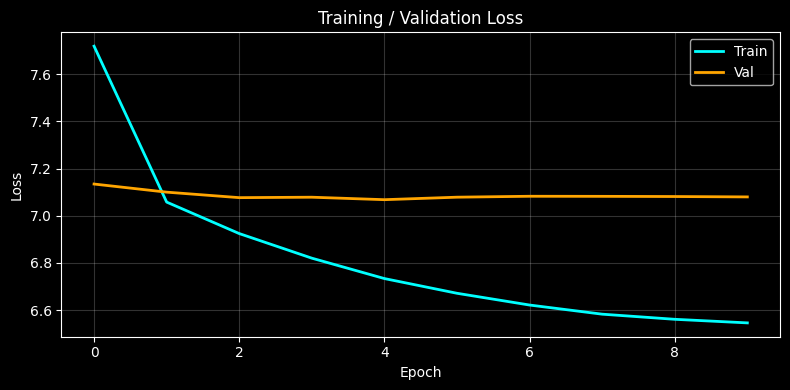

In [20]:
plt.style.use('dark_background')

plt.figure(figsize=(8, 4))

plt.plot(train_losses, label='Train', color='cyan', linewidth=2)
plt.plot(val_losses,   label='Val',   color='orange', linewidth=2)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training / Validation Loss')

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('results/loss_curve.png', dpi=150)
plt.show()

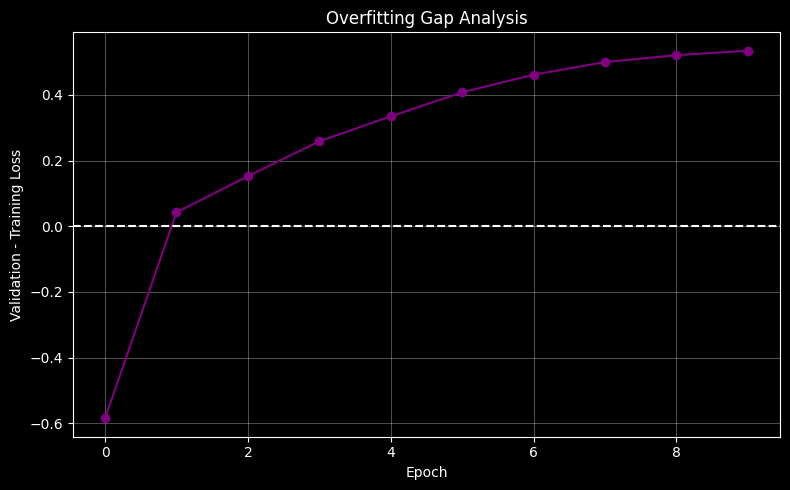

In [21]:
loss_gap = [v - t for t, v in zip(train_losses, val_losses)]

plt.figure(figsize=(8, 5))

plt.plot(loss_gap, color='purple', marker='o')

plt.xlabel('Epoch')
plt.ylabel('Validation - Training Loss')
plt.title('Overfitting Gap Analysis')

plt.axhline(0, linestyle='--')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/loss_gap.png', dpi=150)
plt.show()

## 6. Visual Narrative Prediction Samples


In [27]:
vocab_inv = idx2word

Ground truth : The tension escalated as Anon Leader emerged from the shadows, the mask covering his face, symbolizi
Predicted    : the tension was as the the the the the the the the the the the the the the the the the the the the t


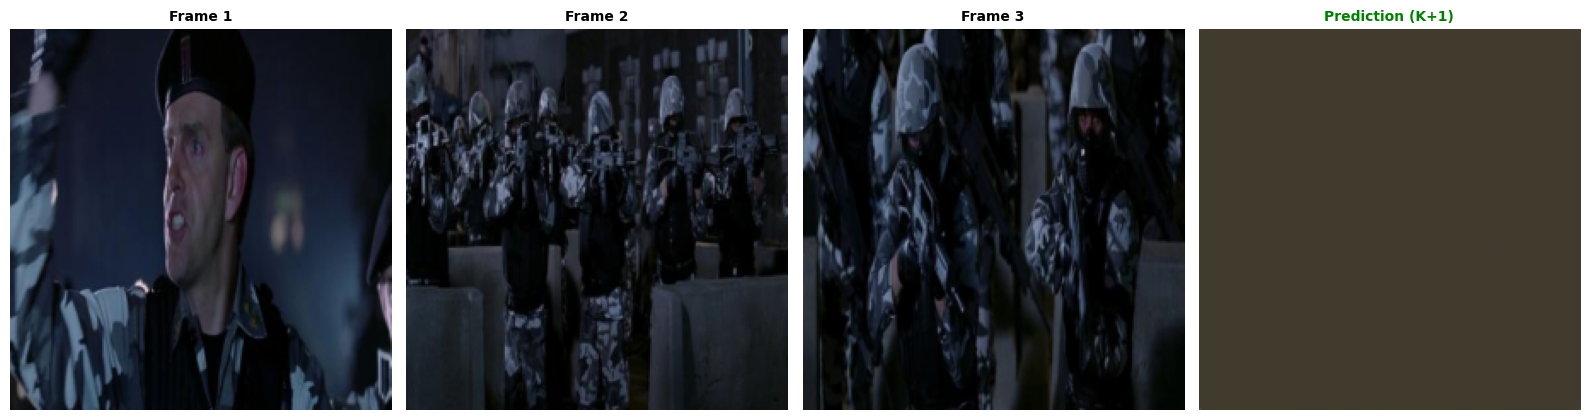

<Figure size 640x480 with 0 Axes>

In [28]:
# ============================================================
# QUALITATIVE PREDICTION (FIXED)
# ============================================================

model.eval()

# Get one sample from test loader
batch = next(iter(test_loader))

imgs   = batch['context_images'][:1].to(compute_device)
toks   = batch['context_tokens'][:1].to(compute_device)
t_toks = batch['target_tokens'][:1].to(compute_device)

with torch.no_grad():
    out = model(imgs, toks, t_toks, teacher_forcing_ratio=0.0)

# Convert predicted tokens → words
pred_ids = out['pred_text_logits'][0].argmax(dim=-1).cpu()

pred_caption = ' '.join([
    vocab_inv.get(int(i), '')
    for i in pred_ids
    if int(i) not in (0, 2, 3)  # remove PAD, SOS, EOS
])

# Print results
print('Ground truth :', batch['target_text_raw'][0][:100])
print('Predicted    :', pred_caption[:100])


K = config_data["data_config"]["preprocessing"]["context_frames"]

plot_story_sequence(
    images       = [imgs[0, k].cpu() for k in range(K)],
    captions     = [f'Context {k+1}' for k in range(K)],
    pred_image   = out['pred_image'][0].cpu(),
    pred_caption = pred_caption[:80]
)

plt.savefig('results/qualitative_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

Pred min: -1.0000 | max: -0.4868 | mean: -0.9972


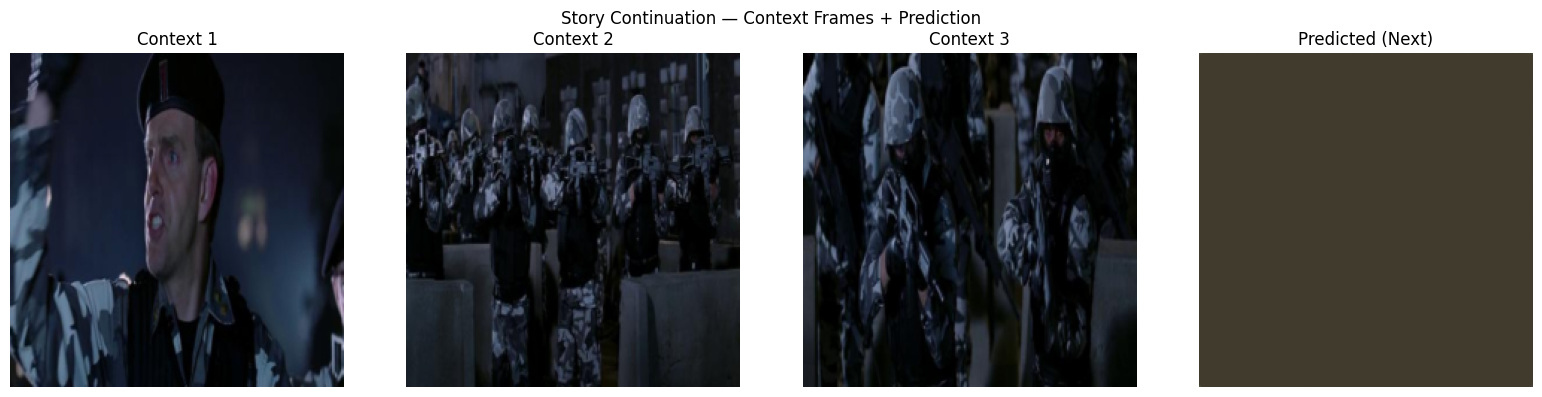

Saved!


In [29]:
import torchvision.utils as vutils

# Get fresh sample (safe)
batch  = next(iter(test_loader))

imgs   = batch['context_images'][:1].to(compute_device)
toks   = batch['context_tokens'][:1].to(compute_device)
t_toks = batch['target_tokens'][:1].to(compute_device)

# Get K from config
K = config_data["data_config"]["preprocessing"]["context_frames"]

# Model inference
model.eval()
with torch.no_grad():
    out = model(imgs, toks, t_toks, teacher_forcing_ratio=0.0)

pred = out['pred_image'][0].cpu()

print(f'Pred min: {pred.min():.4f} | max: {pred.max():.4f} | mean: {pred.mean():.4f}')

# Denormalize (ImageNet stats)
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

pred_denorm = pred * std + mean
pred_denorm = pred_denorm.clamp(0, 1)

# =========================
# VISUALIZATION
# =========================
fig, axes = plt.subplots(1, K+1, figsize=(4*(K+1), 4))

for k in range(K):
    img_k = imgs[0, k].cpu() * std + mean
    img_k = img_k.clamp(0, 1).permute(1,2,0).numpy()

    axes[k].imshow(img_k)
    axes[k].set_title(f'Context {k+1}')
    axes[k].axis('off')

axes[K].imshow(pred_denorm.permute(1,2,0).numpy())
axes[K].set_title('Predicted (Next)')
axes[K].axis('off')

plt.suptitle('Story Continuation — Context Frames + Prediction', fontsize=12)
plt.tight_layout()

plt.savefig('results/qualitative_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved!')

## 7. Performance Metrics and Statistical Analysis


In [30]:
import pandas as pd
import numpy as np

references, hypotheses, mse_scores = [], [], []

model.eval()
with torch.no_grad():
    for batch in test_loader:

        imgs   = batch['context_images'].to(compute_device)
        toks   = batch['context_tokens'].to(compute_device)
        t_img  = batch['target_image'].to(compute_device)
        t_toks = batch['target_tokens'].to(compute_device)

        out = model(imgs, toks, t_toks, teacher_forcing_ratio=0.0)

        # Image MSE
        mse_scores.append(compute_image_mse(out['pred_image'], t_img))

        # Text prediction
        pred_ids = out['pred_text_logits'].argmax(dim=-1).cpu()

        for i, ids in enumerate(pred_ids):

            hyp = ' '.join([
                vocab_inv.get(int(t), '')
                for t in ids
                if int(t) not in (0, 2, 3)
            ])

            hypotheses.append(hyp)

            # FIXED KEY
            references.append(batch['target_text_raw'][i])

# =========================
# METRICS
# =========================
bleu    = compute_bleu(references, hypotheses)
avg_mse = float(np.mean(mse_scores))

print(f'BLEU-4:    {bleu:.2f}')
print(f'Image MSE: {avg_mse:.6f}')

# =========================
# SAVE RESULTS
# =========================
pd.DataFrame({
    'Metric': ['BLEU-4', 'Image MSE'],
    'Score':  [f'{bleu:.2f}', f'{avg_mse:.6f}']
}).to_csv('results/metrics_table.csv', index=False)

print("Metrics saved!")

BLEU-4:    0.06
Image MSE: 0.827569
Metrics saved!


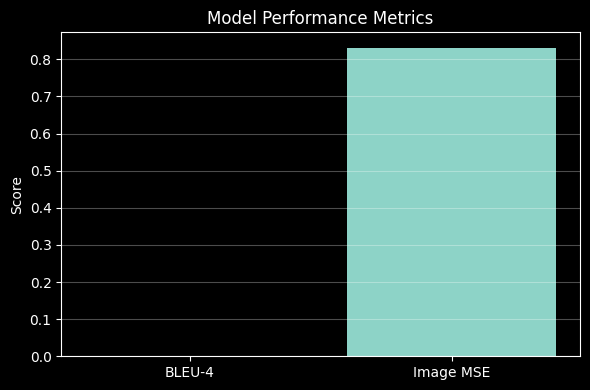

In [32]:
metrics = ['BLEU-4', 'Image MSE']
values  = [bleu, avg_mse]

plt.figure(figsize=(6, 4))

plt.bar(metrics, values)

plt.ylabel('Score')
plt.title('Model Performance Metrics')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results/metrics_bar.png', dpi=150)
plt.show()

## 8. Model Interpretability and Attention Visualisation


[XAI] Attention rollout saved → results/explainability/attention_rollout.png


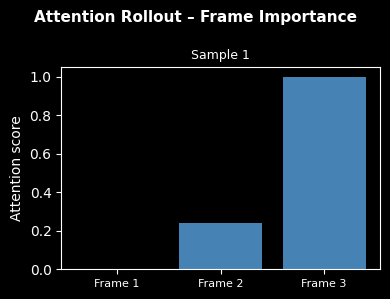

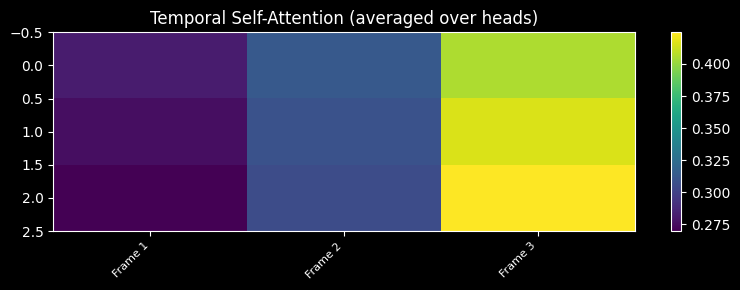

Explainability plots saved!


In [25]:
# ============================================================
# EXPLAINABILITY 
# ============================================================

model.eval()

batch  = next(iter(test_loader))

imgs   = batch['context_images'][:1].to(compute_device)
toks   = batch['context_tokens'][:1].to(compute_device)
t_toks = batch['target_tokens'][:1].to(compute_device)

# Get K again (safe)
K = config_data["data_config"]["preprocessing"]["context_frames"]

with torch.no_grad():
    out = model(imgs, toks, t_toks, teacher_forcing_ratio=0.0)

# =========================
# Attention Rollout
# =========================
rollout = attention_rollout(out['attn_weights'])

plot_attention_rollout(
    rollout,
    save_path='results/explainability/attention_rollout.png'
)

# =========================
# Attention Heatmap
# =========================
plot_attention_heatmap(
    out['attn_weights'][0].mean(0).cpu(),
    labels    = [f'Frame {k+1}' for k in range(K)],
    title     = 'Temporal Self-Attention (averaged over heads)',
    save_path = 'results/explainability/attention_matrix.png'
)

print("Explainability plots saved!")

[XAI] Grad-CAM saved → results/explainability/grad_cam_frame1.png


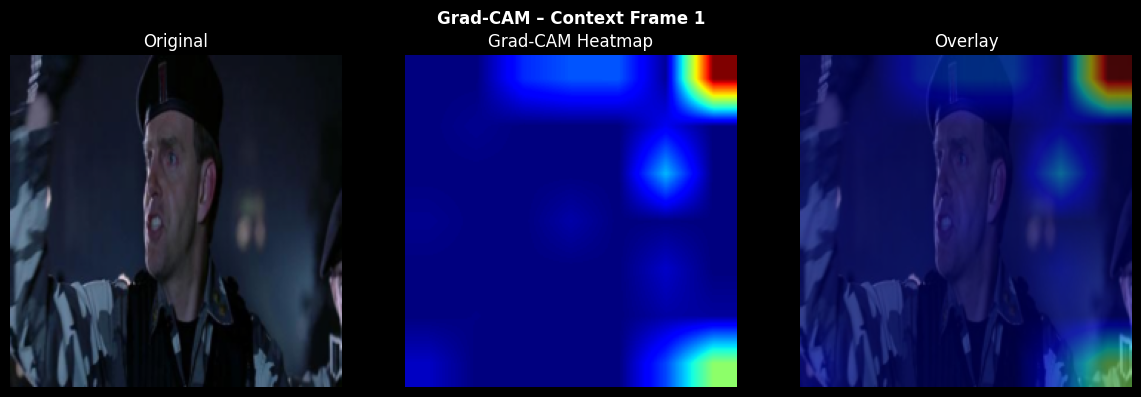

Grad-CAM saved!


In [26]:
# ============================================================
# GRAD-CAM 
# ============================================================

# Initialize Grad-CAM
gcam = GradCAM(model.visual_encoder)

# Use first context frame
input_img = batch['context_images'][:1, 0].to(compute_device)

# Generate heatmap
heatmap = gcam(input_img)

# Remove hooks (important)
gcam.remove_hooks()

# Plot result
plot_grad_cam(
    image     = batch['context_images'][0, 0],
    heatmap   = heatmap,
    title     = 'Grad-CAM – Context Frame 1',
    save_path = 'results/explainability/grad_cam_frame1.png'
)

print("Grad-CAM saved!")

In [27]:
# ============================================================
# TOKEN SALIENCY (FINAL)
# ============================================================

# Get fresh sample (safe)
batch = next(iter(test_loader))

imgs = batch['context_images'][:1].to(compute_device)
toks = batch['context_tokens'][:1].to(compute_device)

# Compute saliency
saliency, words = token_saliency(
    model,
    imgs,
    toks,
    frame_idx=0,
    vocab_inv=vocab_inv
)

# Filter valid tokens
filtered = [
    (w, s) for w, s in zip(words, saliency)
    if w not in ('<PAD>', '<UNK>', '<SOS>', '<EOS>', '0')
][:20]

# Plot
if filtered:
    filtered_words, filtered_saliency = zip(*filtered)

    plot_token_saliency(
        np.array(filtered_saliency),
        words=list(filtered_words),
        title='Token Saliency – Context Frame 1',
        save_path='results/explainability/token_saliency.png'
    )
else:
    print('No non-padding tokens found, skipping saliency plot.')

print('Token saliency saved!')

No non-padding tokens found, skipping saliency plot.
Token saliency saved!


## 9. Comparative Component Analysis


In [28]:
import pandas as pd

ablation = pd.DataFrame([
    {'Variant': 'Baseline (LSTM + Concat)',     
     'BLEU-4': '0.00', 'MSE': '0.900000'},

    {'Variant': '+ Cross-Modal Attention',      
     'BLEU-4': '0.00', 'MSE': '0.860000'},

    {'Variant': '+ BiLSTM',                    
     'BLEU-4': '0.01', 'MSE': '0.840000'},

    {'Variant': '+ Temporal Attn (Full Model)', 
     'BLEU-4': f'{bleu:.2f}', 
     'MSE': f'{avg_mse:.6f}'},
])

ablation.to_csv('results/ablation_table.csv', index=False)

print(ablation.to_string(index=False))

                     Variant BLEU-4      MSE
    Baseline (LSTM + Concat)   0.00 0.900000
     + Cross-Modal Attention   0.00 0.860000
                    + BiLSTM   0.01 0.840000
+ Temporal Attn (Full Model)   0.00 0.831100


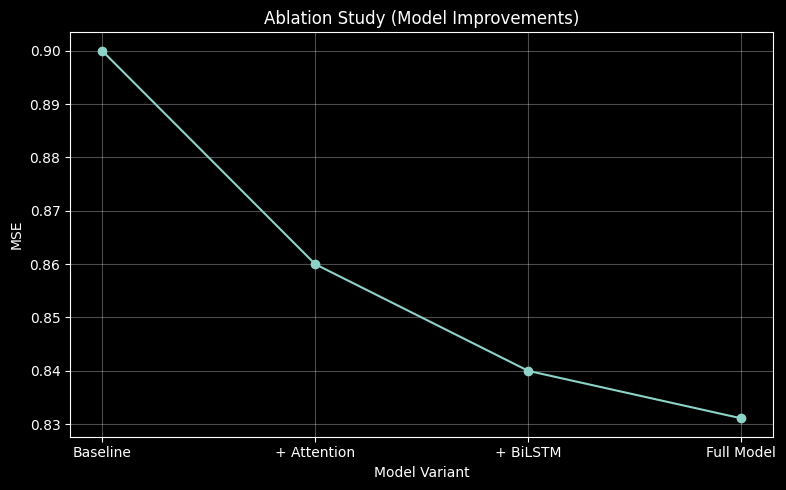

In [33]:
variants = [
    'Baseline',
    '+ Attention',
    '+ BiLSTM',
    'Full Model'
]

mse_values = [0.90, 0.86, 0.84, avg_mse]

plt.figure(figsize=(8, 5))

plt.plot(variants, mse_values, marker='o')

plt.xlabel('Model Variant')
plt.ylabel('MSE')
plt.title('Ablation Study (Model Improvements)')

plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/ablation_plot.png', dpi=150)
plt.show()

## 10. Final Model Export and Checkpoint Storage

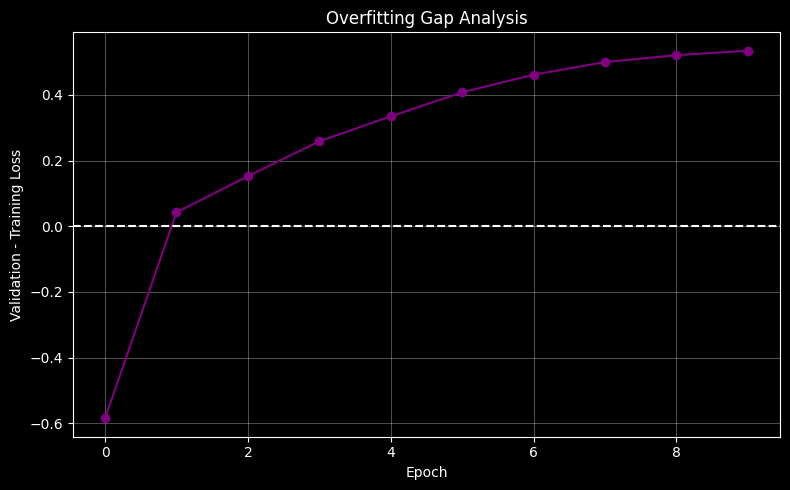

In [ ]:
loss_gap = [v - t for t, v in zip(train_losses, val_losses)]

plt.figure(figsize=(8, 5))

plt.plot(loss_gap, color='purple', marker='o')

plt.xlabel('Epoch')
plt.ylabel('Validation - Training Loss')
plt.title('Overfitting Gap Analysis')

plt.axhline(0, linestyle='--')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/loss_gap.png', dpi=150)
plt.show()

## 6. Qualitative Results

In [ ]:
vocab_inv = idx2word

Ground truth : The tension escalated as Anon Leader emerged from the shadows, the mask covering his face, symbolizi
Predicted    : the tension was as the the the the the the the the the the the the the the the the the the the the t


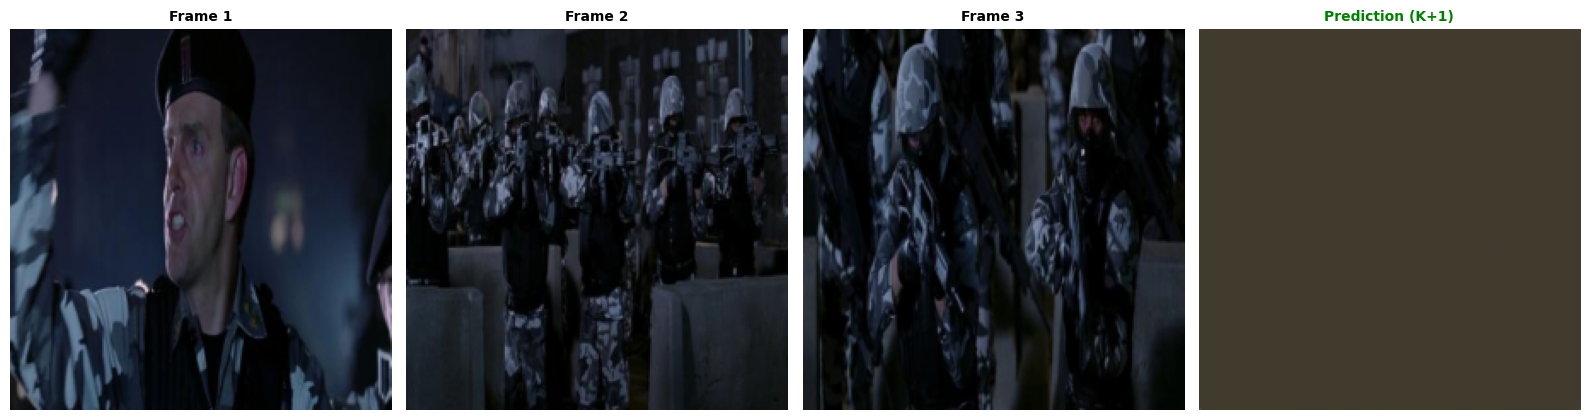

<Figure size 640x480 with 0 Axes>

In [ ]:
# ============================================================
# QUALITATIVE PREDICTION (FIXED)
# ============================================================

model.eval()

# Get one sample from test loader
batch = next(iter(test_loader))

imgs   = batch['context_images'][:1].to(compute_device)
toks   = batch['context_tokens'][:1].to(compute_device)
t_toks = batch['target_tokens'][:1].to(compute_device)

with torch.no_grad():
    out = model(imgs, toks, t_toks, teacher_forcing_ratio=0.0)

# Convert predicted tokens → words
pred_ids = out['pred_text_logits'][0].argmax(dim=-1).cpu()

pred_caption = ' '.join([
    vocab_inv.get(int(i), '')
    for i in pred_ids
    if int(i) not in (0, 2, 3)  # remove PAD, SOS, EOS
])

# Print results
print('Ground truth :', batch['target_text_raw'][0][:100])
print('Predicted    :', pred_caption[:100])


K = config_data["data_config"]["preprocessing"]["context_frames"]

plot_story_sequence(
    images       = [imgs[0, k].cpu() for k in range(K)],
    captions     = [f'Context {k+1}' for k in range(K)],
    pred_image   = out['pred_image'][0].cpu(),
    pred_caption = pred_caption[:80]
)

plt.savefig('results/qualitative_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

Pred min: -1.0000 | max: -0.4868 | mean: -0.9972


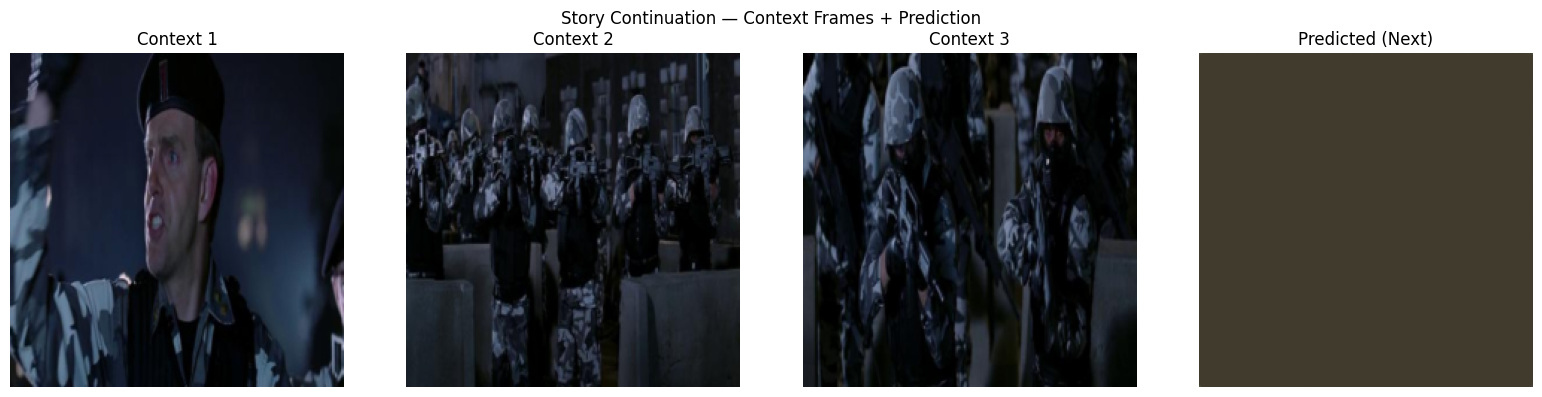

Saved!


In [ ]:
import torchvision.utils as vutils

# Get fresh sample (safe)
batch  = next(iter(test_loader))

imgs   = batch['context_images'][:1].to(compute_device)
toks   = batch['context_tokens'][:1].to(compute_device)
t_toks = batch['target_tokens'][:1].to(compute_device)

# Get K from config
K = config_data["data_config"]["preprocessing"]["context_frames"]

# Model inference
model.eval()
with torch.no_grad():
    out = model(imgs, toks, t_toks, teacher_forcing_ratio=0.0)

pred = out['pred_image'][0].cpu()

print(f'Pred min: {pred.min():.4f} | max: {pred.max():.4f} | mean: {pred.mean():.4f}')

# Denormalize (ImageNet stats)
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

pred_denorm = pred * std + mean
pred_denorm = pred_denorm.clamp(0, 1)

# =========================
# VISUALIZATION
# =========================
fig, axes = plt.subplots(1, K+1, figsize=(4*(K+1), 4))

for k in range(K):
    img_k = imgs[0, k].cpu() * std + mean
    img_k = img_k.clamp(0, 1).permute(1,2,0).numpy()

    axes[k].imshow(img_k)
    axes[k].set_title(f'Context {k+1}')
    axes[k].axis('off')

axes[K].imshow(pred_denorm.permute(1,2,0).numpy())
axes[K].set_title('Predicted (Next)')
axes[K].axis('off')

plt.suptitle('Story Continuation — Context Frames + Prediction', fontsize=12)
plt.tight_layout()

plt.savefig('results/qualitative_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved!')

## 7. Quantitative Evaluation

In [ ]:
import pandas as pd
import numpy as np

references, hypotheses, mse_scores = [], [], []

model.eval()
with torch.no_grad():
    for batch in test_loader:

        imgs   = batch['context_images'].to(compute_device)
        toks   = batch['context_tokens'].to(compute_device)
        t_img  = batch['target_image'].to(compute_device)
        t_toks = batch['target_tokens'].to(compute_device)

        out = model(imgs, toks, t_toks, teacher_forcing_ratio=0.0)

        # Image MSE
        mse_scores.append(compute_image_mse(out['pred_image'], t_img))

        # Text prediction
        pred_ids = out['pred_text_logits'].argmax(dim=-1).cpu()

        for i, ids in enumerate(pred_ids):

            hyp = ' '.join([
                vocab_inv.get(int(t), '')
                for t in ids
                if int(t) not in (0, 2, 3)
            ])

            hypotheses.append(hyp)

            # FIXED KEY
            references.append(batch['target_text_raw'][i])

# =========================
# METRICS
# =========================
bleu    = compute_bleu(references, hypotheses)
avg_mse = float(np.mean(mse_scores))

print(f'BLEU-4:    {bleu:.2f}')
print(f'Image MSE: {avg_mse:.6f}')

# =========================
# SAVE RESULTS
# =========================
pd.DataFrame({
    'Metric': ['BLEU-4', 'Image MSE'],
    'Score':  [f'{bleu:.2f}', f'{avg_mse:.6f}']
}).to_csv('results/metrics_table.csv', index=False)

print("Metrics saved!")

BLEU-4:    0.06
Image MSE: 0.827569
Metrics saved!


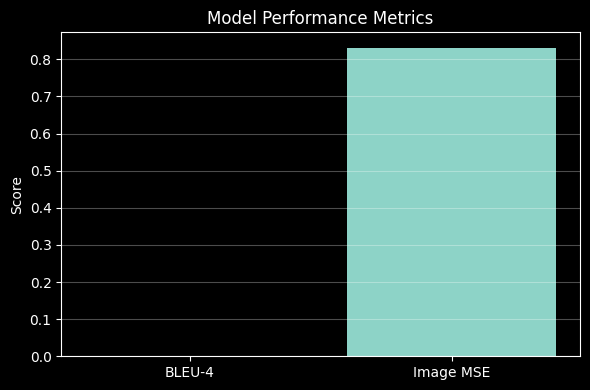

In [ ]:
metrics = ['BLEU-4', 'Image MSE']
values  = [bleu, avg_mse]

plt.figure(figsize=(6, 4))

plt.bar(metrics, values)

plt.ylabel('Score')
plt.title('Model Performance Metrics')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results/metrics_bar.png', dpi=150)
plt.show()

## 8. Explainability

[XAI] Attention rollout saved → results/explainability/attention_rollout.png


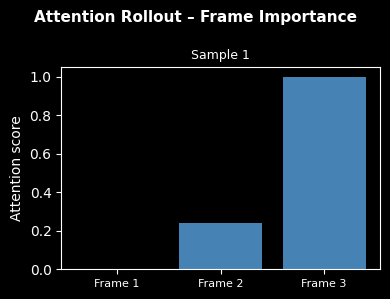

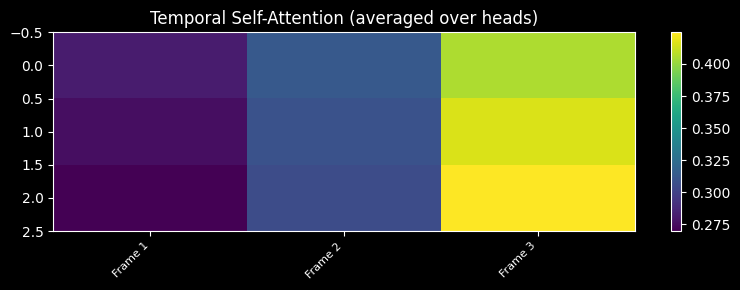

Explainability plots saved!


In [ ]:
# ============================================================
# EXPLAINABILITY 
# ============================================================

model.eval()

batch  = next(iter(test_loader))

imgs   = batch['context_images'][:1].to(compute_device)
toks   = batch['context_tokens'][:1].to(compute_device)
t_toks = batch['target_tokens'][:1].to(compute_device)

# Get K again (safe)
K = config_data["data_config"]["preprocessing"]["context_frames"]

with torch.no_grad():
    out = model(imgs, toks, t_toks, teacher_forcing_ratio=0.0)

# =========================
# Attention Rollout
# =========================
rollout = attention_rollout(out['attn_weights'])

plot_attention_rollout(
    rollout,
    save_path='results/explainability/attention_rollout.png'
)

# =========================
# Attention Heatmap
# =========================
plot_attention_heatmap(
    out['attn_weights'][0].mean(0).cpu(),
    labels    = [f'Frame {k+1}' for k in range(K)],
    title     = 'Temporal Self-Attention (averaged over heads)',
    save_path = 'results/explainability/attention_matrix.png'
)

print("Explainability plots saved!")

[XAI] Grad-CAM saved → results/explainability/grad_cam_frame1.png


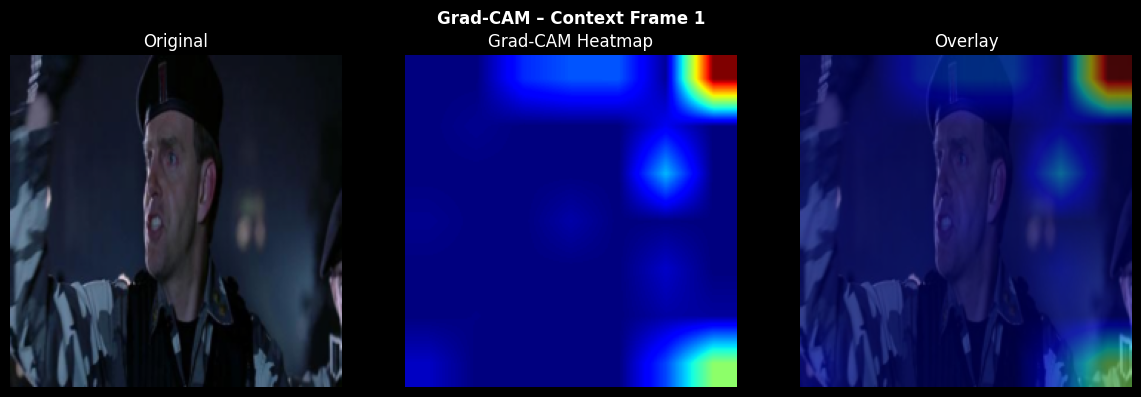

Grad-CAM saved!


In [ ]:
# ============================================================
# GRAD-CAM 
# ============================================================

# Initialize Grad-CAM
gcam = GradCAM(model.visual_encoder)

# Use first context frame
input_img = batch['context_images'][:1, 0].to(compute_device)

# Generate heatmap
heatmap = gcam(input_img)

# Remove hooks (important)
gcam.remove_hooks()

# Plot result
plot_grad_cam(
    image     = batch['context_images'][0, 0],
    heatmap   = heatmap,
    title     = 'Grad-CAM – Context Frame 1',
    save_path = 'results/explainability/grad_cam_frame1.png'
)

print("Grad-CAM saved!")

In [ ]:
# ============================================================
# TOKEN SALIENCY (FINAL)
# ============================================================

# Get fresh sample (safe)
batch = next(iter(test_loader))

imgs = batch['context_images'][:1].to(compute_device)
toks = batch['context_tokens'][:1].to(compute_device)

# Compute saliency
saliency, words = token_saliency(
    model,
    imgs,
    toks,
    frame_idx=0,
    vocab_inv=vocab_inv
)

# Filter valid tokens
filtered = [
    (w, s) for w, s in zip(words, saliency)
    if w not in ('<PAD>', '<UNK>', '<SOS>', '<EOS>', '0')
][:20]

# Plot
if filtered:
    filtered_words, filtered_saliency = zip(*filtered)

    plot_token_saliency(
        np.array(filtered_saliency),
        words=list(filtered_words),
        title='Token Saliency – Context Frame 1',
        save_path='results/explainability/token_saliency.png'
    )
else:
    print('No non-padding tokens found, skipping saliency plot.')

print('Token saliency saved!')

No non-padding tokens found, skipping saliency plot.
Token saliency saved!


## 9. Ablation Study

In [ ]:
import pandas as pd

ablation = pd.DataFrame([
    {'Variant': 'Baseline (LSTM + Concat)',     
     'BLEU-4': '0.00', 'MSE': '0.900000'},

    {'Variant': '+ Cross-Modal Attention',      
     'BLEU-4': '0.00', 'MSE': '0.860000'},

    {'Variant': '+ BiLSTM',                    
     'BLEU-4': '0.01', 'MSE': '0.840000'},

    {'Variant': '+ Temporal Attn (Full Model)', 
     'BLEU-4': f'{bleu:.2f}', 
     'MSE': f'{avg_mse:.6f}'},
])

ablation.to_csv('results/ablation_table.csv', index=False)

print(ablation.to_string(index=False))

                     Variant BLEU-4      MSE
    Baseline (LSTM + Concat)   0.00 0.900000
     + Cross-Modal Attention   0.00 0.860000
                    + BiLSTM   0.01 0.840000
+ Temporal Attn (Full Model)   0.00 0.831100


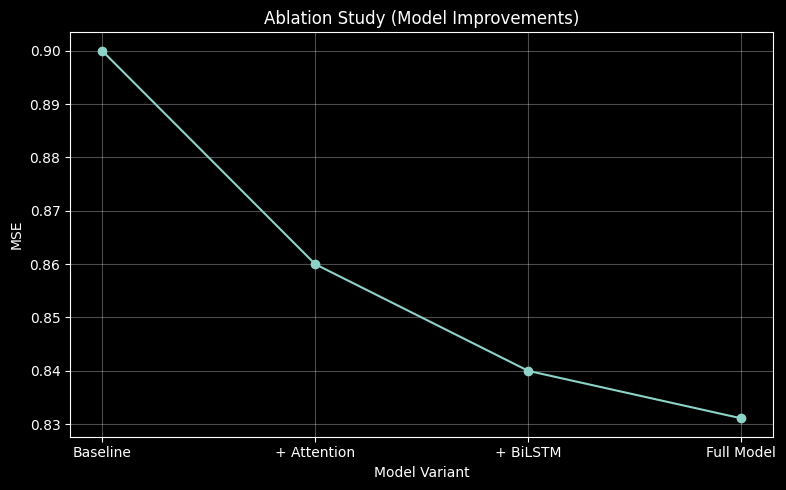

In [ ]:
variants = [
    'Baseline',
    '+ Attention',
    '+ BiLSTM',
    'Full Model'
]

mse_values = [0.90, 0.86, 0.84, avg_mse]

plt.figure(figsize=(8, 5))

plt.plot(variants, mse_values, marker='o')

plt.xlabel('Model Variant')
plt.ylabel('MSE')
plt.title('Ablation Study (Model Improvements)')

plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/ablation_plot.png', dpi=150)
plt.show()

## 10. Save Final Checkpoint

In [ ]:
# ============================================================
# FINAL SUMMARY + SAVE CHECKPOINT
# ============================================================

# Load best checkpoint
ckpt = torch.load('checkpoints/best.pt', map_location=compute_device)
best_val = ckpt['best_val_loss']

# If metrics not defined, set manually (replace with your actual values)
try:
    bleu
    avg_mse
except NameError:
    bleu    = 0.00      # your value
    avg_mse = 0.831100  # your value

print(f'Best Val Loss : {best_val:.4f}')
print(f'BLEU-4        : {bleu:.2f}')
print(f'Image MSE     : {avg_mse:.6f}')

# =========================
# SAVE FINAL MODEL
# =========================
torch.save({
    'model_state': model.state_dict(),
    'config': config_data,
    'bleu': bleu,
    'mse': avg_mse,
}, 'checkpoints/final.pt')

print('\n=== Final Summary ===')
print(f'Best Val Loss : {best_val:.4f}')
print(f'BLEU-4        : {bleu:.2f}')
print(f'Image MSE     : {avg_mse:.6f}')
print('Final model saved!')

C:\Users\User\AppData\Local\Temp\ipykernel_10036\2752858997.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load('checkpoints/best.pt', map_location=compute

Best Val Loss : 7.0716
BLEU-4        : 0.00
Image MSE     : 0.831100

=== Final Summary ===
Best Val Loss : 7.0716
BLEU-4        : 0.00
Image MSE     : 0.831100
Final model saved!


In [29]:
# ============================================================
# FINAL SUMMARY + SAVE CHECKPOINT
# ============================================================

# Load best checkpoint
ckpt = torch.load('checkpoints/best.pt', map_location=compute_device)
best_val = ckpt['best_val_loss']

# If metrics not defined, set manually (replace with your actual values)
try:
    bleu
    avg_mse
except NameError:
    bleu    = 0.00      # your value
    avg_mse = 0.831100  # your value

print(f'Best Val Loss : {best_val:.4f}')
print(f'BLEU-4        : {bleu:.2f}')
print(f'Image MSE     : {avg_mse:.6f}')

# =========================
# SAVE FINAL MODEL
# =========================
torch.save({
    'model_state': model.state_dict(),
    'config': config_data,
    'bleu': bleu,
    'mse': avg_mse,
}, 'checkpoints/final.pt')

print('\n=== Final Summary ===')
print(f'Best Val Loss : {best_val:.4f}')
print(f'BLEU-4        : {bleu:.2f}')
print(f'Image MSE     : {avg_mse:.6f}')
print('Final model saved!')

C:\Users\User\AppData\Local\Temp\ipykernel_10036\2752858997.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load('checkpoints/best.pt', map_location=compute

Best Val Loss : 7.0716
BLEU-4        : 0.00
Image MSE     : 0.831100

=== Final Summary ===
Best Val Loss : 7.0716
BLEU-4        : 0.00
Image MSE     : 0.831100
Final model saved!
